In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

X = df.drop('Attrition', axis=1)
y = df['Attrition'].map({"Yes" : 1, "No" : 0})

# for col in df.columns:
#     print(col, df[col].unique(), "\n")

# print(df.info())

# print(df.duplicated().sum())
print((y==0).sum())
print(df.shape)

1233
(1470, 35)


In [2]:
# Splits data with 80/20 ratio
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
# Preprocess and Model's pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

need_encode_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

preprocess = ColumnTransformer(
    transformers = [
        ('encode_cols', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), need_encode_cols)
    ],
    remainder="passthrough"
)

pipeline = Pipeline([
    ('preprocess_encode', preprocess),
    ('model', RandomForestClassifier(oob_score=True, random_state=42))
])

In [4]:
# Finetune model
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "model__n_estimators" : [100, 200, 300, 500],
    "model__max_depth" : [None, 5, 10, 15, 20],
    "model__min_samples_split" : [2, 5, 10],
    "model__min_samples_leaf" : [1, 2, 4],
    "model__class_weight" : [None, "balanced", "balanced_subsample"]
}

random_search = RandomizedSearchCV(
    pipeline,
    param_grid,
    n_iter=30,
    scoring='recall',
    cv=5,
    n_jobs=-1,
    random_state=42
)

In [5]:
# Train model
random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__class_weight': [None, 'balanced', ...], 'model__max_depth': [None, 5, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this`

In [6]:
predictions = random_search.predict(X_test)


print("Best Hyperparameter Found :\n",random_search.best_params_, "\n")
print(predictions)

Best Hyperparameter Found :
 {'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_depth': 5, 'model__class_weight': 'balanced'} 

[1 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 1 0
 0 0 1 0 1 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 1 1 0 1 1 0 0 0 0 0 1 1 1 0 0 0
 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 0 1 1 0 0 0 1 0
 0 0 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0
 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 1 0
 0 0 0 0 0 0 0 0 1 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0]


In [8]:
# Classification Report and Confusion Matrix
from sklearn.metrics import classification_report, confusion_matrix

rs_report_df = pd.DataFrame(random_search.cv_results_)
rs_report = rs_report_df.sort_values(by="mean_test_score", ascending=False, ignore_index=True)

# print(rs_report[['param_model__n_estimators', 'param_model__min_samples_split', 'param_model__min_samples_leaf', 'param_model__max_depth', 'param_model__class_weight', 'mean_test_score', 'std_test_score']].head(5))

print(classification_report(y_test, predictions))
print(f"\n\nConfusion Matrix\n{confusion_matrix(y_test, predictions)}")

# Model
best_estimator = random_search.best_estimator_
model = best_estimator.named_steps['model']
print(round(model.oob_score_*100, 2))



              precision    recall  f1-score   support

           0       0.92      0.83      0.88       247
           1       0.42      0.64      0.51        47

    accuracy                           0.80       294
   macro avg       0.67      0.74      0.69       294
weighted avg       0.84      0.80      0.82       294



Confusion Matrix
[[206  41]
 [ 17  30]]
82.57


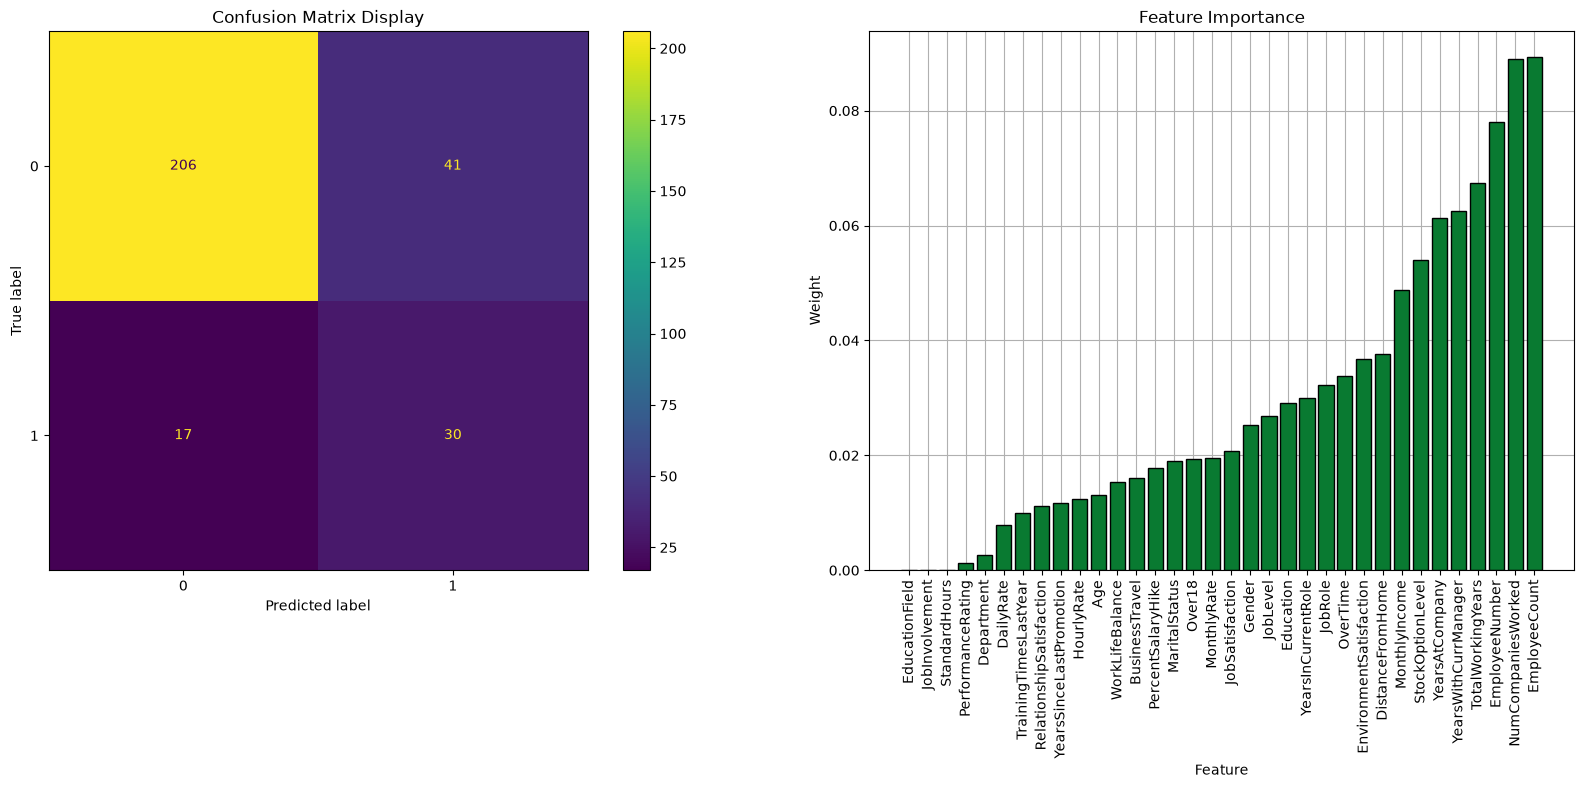

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


importance = pd.Series(
    model.feature_importances_,
    index = X.columns
).sort_values()


fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Confusion Matrix Visualization
ConfusionMatrixDisplay.from_predictions(y_test, predictions, ax=axes[0])
axes[0].set_title("Confusion Matrix Display")

# Feature Importance Visualization
axes[1].bar(importance.index, importance.values, color="#097A31", edgecolor="#000000")
axes[1].set_title("Feature Importance")
axes[1].set_xlabel("Feature")
axes[1].set_ylabel("Score")
axes[1].grid(True)
axes[1].set_axisbelow(True)
axes[1].tick_params(axis='x', rotation=90)

[Text(0.5, 0.9, 'MonthlyIncome <= 1.5\ngini = 0.5\nsamples = 635\nvalue = [602, 574]\nclass = Will Leave'),
 Text(0.25, 0.7, 'EmployeeCount <= 0.5\ngini = 0.459\nsamples = 241\nvalue = [186, 336]\nclass = Will Stay'),
 Text(0.375, 0.8, 'True  '),
 Text(0.125, 0.5, 'EmployeeNumber <= 31.5\ngini = 0.5\nsamples = 160\nvalue = [154, 147]\nclass = Will Leave'),
 Text(0.0625, 0.3, 'YearsInCurrentRole <= 0.5\ngini = 0.443\nsamples = 80\nvalue = [56.0, 113.0]\nclass = Will Stay'),
 Text(0.03125, 0.1, '\n  (...)  \n'),
 Text(0.09375, 0.1, '\n  (...)  \n'),
 Text(0.1875, 0.3, 'EmployeeNumber <= 54.0\ngini = 0.382\nsamples = 80\nvalue = [98, 34]\nclass = Will Leave'),
 Text(0.15625, 0.1, '\n  (...)  \n'),
 Text(0.21875, 0.1, '\n  (...)  \n'),
 Text(0.375, 0.5, 'DistanceFromHome <= 4.0\ngini = 0.248\nsamples = 81\nvalue = [32, 189]\nclass = Will Stay'),
 Text(0.3125, 0.3, 'JobSatisfaction <= 34.0\ngini = 0.167\nsamples = 37\nvalue = [9, 89]\nclass = Will Stay'),
 Text(0.28125, 0.1, '\n  (...)  \n'

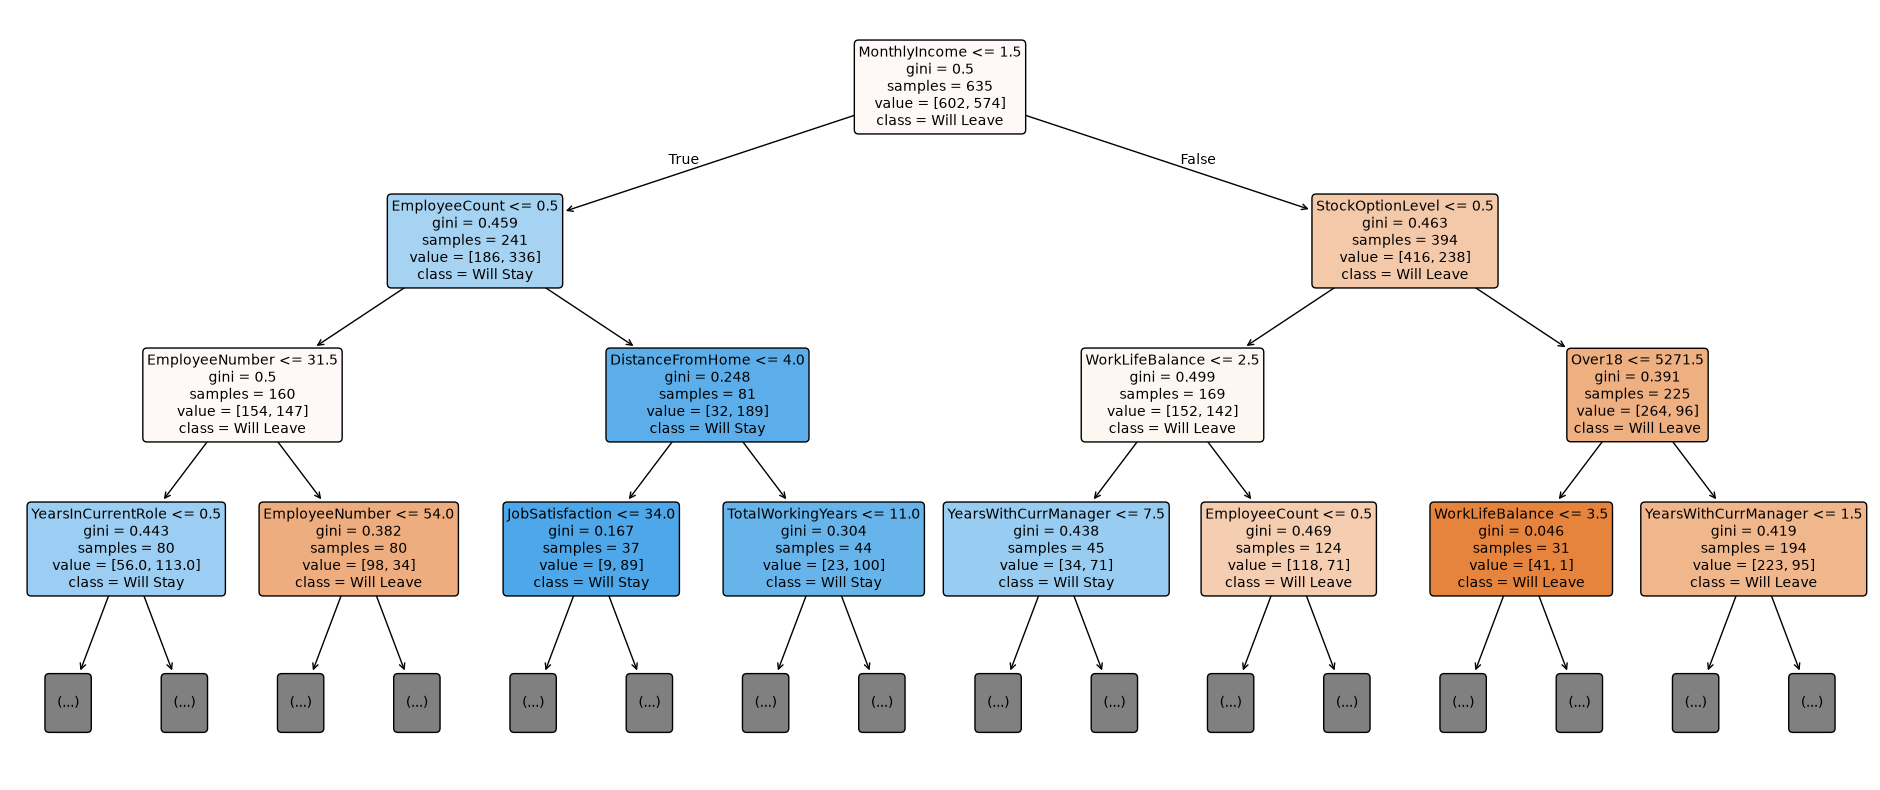

In [73]:
# Visualize 1st tree in the forest
from sklearn.tree import plot_tree

fig, axes = plt.subplots(figsize=(24, 10))

plot_tree(
    model.estimators_[0],
    max_depth = 3,
    feature_names = X.columns,
    class_names = ["Will Leave", "Will Stay"],
    filled = True,
    rounded = True,
    fontsize=10
)
